# LSTM do zero: geração de texto com célula de memória

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flavioluizseixas/aprendizado-de-maquina-para-saude/blob/main/notebooks/RNN/lstm_do_zero_d2l.ipynb)

Terceiro notebook da série, baseado na seção
[9.2 — Memória Longa de Curto Prazo (LSTM)](https://pt.d2l.ai/chapter_recurrent-modern/lstm.html)
do livro *Dive into Deep Learning* (D2L), de Aston Zhang, Zachary C. Lipton,
Mu Li e Alexander J. Smola.

Implementamos uma **LSTM do zero em PyTorch** para prever o próximo caractere
de *The Time Machine*, de H. G. Wells. Além do estado oculto `H`, a rede
mantém uma célula de memória `C`, controlada por portas de entrada,
esquecimento e saída.

Os pesos, as portas, a recorrência, a projeção de saída, o recorte de gradientes
e o SGD são explícitos. O PyTorch fornece operações com tensores, entropia
cruzada e diferenciação automática; a retropropagação não é derivada
manualmente. A implementação do modelo não usa `nn.LSTM` nem `nn.Linear`.

**Como executar:** abra no Jupyter, VS Code ou Colab e execute as células em
ordem. Este arquivo contém todas as funções necessárias; não depende da
execução dos notebooks anteriores nem do pacote `d2l`. O corpus é baixado
para `data/timemachine.txt` apenas se ainda não existir.

O perfil padrão `livro` usa **256 unidades ocultas e 500 épocas**. Para uma
execução curta, selecione `PERFIL = "rapido"`. A comparação com amostragem
aleatória é uma extensão didática; para treinar apenas com amostragem
sequencial, selecione `TREINAR_ALEATORIO = False`.

Esta adaptação inclui explicações em português, funções auxiliares completas,
inspeção das portas e gráficos. O material adaptado é disponibilizado sob
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), conforme a
[licença do D2L](https://github.com/d2l-ai/d2l-en/blob/master/LICENSE).


## 1. Dependências e configuração

São necessários Python 3.9 ou superior, PyTorch e Matplotlib. Se os imports
falharem, descomente e execute a instalação abaixo no kernel do notebook.


In [1]:
# Descomente na primeira execução se as bibliotecas ainda não estiverem instaladas.
# %pip install torch matplotlib


In [2]:
import hashlib
import math
import random
import re
import time
from collections import Counter
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F


def fixar_semente(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
PERFIL = "livro"  # "rapido" ou "livro"
PERFIS = {
    "rapido": {"num_hiddens": 128, "num_epochs": 50},
    "livro": {"num_hiddens": 256, "num_epochs": 500},
}
config = PERFIS[PERFIL]
batch_size = 32
num_steps = 35
max_tokens = 10_000
num_hiddens = config["num_hiddens"]
num_epochs = config["num_epochs"]
lr = 1.0
clip_theta = 1.0
TREINAR_ALEATORIO = True

# CPU funciona em qualquer plataforma; CUDA é usada quando disponível.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Matrizes pequenas podem ser mais rápidas com apenas uma thread de CPU.
torch.set_num_threads(1)
fixar_semente(SEED)

print(f"PyTorch {torch.__version__} | dispositivo: {device}")
print(f"Perfil: {PERFIL} | unidades ocultas: {num_hiddens} | épocas: {num_epochs}")


PyTorch 2.8.0 | dispositivo: cpu
Perfil: livro | unidades ocultas: 256 | épocas: 500


## 2. Corpus e vocabulário

O pré-processamento segue a [seção 8.2 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/text-preprocessing.html):
mantemos letras e espaços, convertemos para minúsculas e concatenamos as linhas
sem inserir separadores extras. Assim, algumas palavras no limite entre linhas
ficam unidas, como nos dados do capítulo.

O vocabulário é construído antes de limitar o corpus a 10.000 caracteres.
O índice zero representa `<unk>`, reservado para caracteres desconhecidos.
Os dados estão em inglês; por isso, os textos gerados também estarão.


In [3]:
DATA_URL = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
DATA_SHA1 = "090b5e7e70c295757f55df93cb0a180b9691891a"
DATA_PATH = Path("data/timemachine.txt")


def ler_time_machine(path=DATA_PATH):
    path = Path(path)
    if not path.exists():
        try:
            with urlopen(DATA_URL, timeout=60) as response:
                data = response.read()
        except (URLError, TimeoutError) as error:
            raise RuntimeError(
                f"Não foi possível baixar o corpus. Baixe {DATA_URL} "
                f"manualmente, salve em {path.resolve()} e execute novamente."
            ) from error
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError("O corpus baixado não corresponde ao arquivo do D2L.")
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(data)
    else:
        data = path.read_bytes()
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError(f"Checksum incorreto: substitua {path} pelo corpus do D2L.")

    return [
        re.sub(r"[^A-Za-z]+", " ", line).strip().lower()
        for line in data.decode("utf-8").splitlines()
    ]


class Vocab:
    def __init__(self, text):
        self.idx_to_token = ["<unk>"] + [
            token for token, count in Counter(text).most_common()
        ]
        self.token_to_idx = {
            token: index for index, token in enumerate(self.idx_to_token)
        }

    def __len__(self):
        return len(self.idx_to_token)

    def encode(self, text):
        return [self.token_to_idx.get(char, 0) for char in text]

    def decode(self, indices):
        return "".join(self.idx_to_token[int(index)] for index in indices)


lines = ler_time_machine()
text = "".join(lines)
vocab = Vocab(text)
corpus = vocab.encode(text)[:max_tokens]
print(f"Linhas: {len(lines):,} | caracteres usados: {len(corpus):,}")
print(f"Tamanho do vocabulário: {len(vocab)}")
print("Tokens:", vocab.idx_to_token)
print("Trecho:", vocab.decode(corpus[:100]))


Linhas: 3,221 | caracteres usados: 10,000
Tamanho do vocabulário: 28
Tokens: ['<unk>', ' ', 'e', 't', 'a', 'i', 'n', 'o', 's', 'h', 'r', 'd', 'l', 'm', 'u', 'c', 'f', 'w', 'g', 'y', 'p', 'b', 'v', 'k', 'x', 'z', 'j', 'q']
Trecho: the time machine by h g wellsithe time traveller for so it will be convenient to speak of himwas exp


## 3. Minibatches sequenciais e aleatórios

Cada entrada `X` contém índices de caracteres. O alvo `Y` contém os caracteres
seguintes: para `X = "time"`, teríamos `Y = "ime "`.

Na **amostragem sequencial**, uma linha do próximo lote continua a mesma linha
do lote anterior. Na **amostragem aleatória**, embaralhamos subsequências inteiras;
a ordem dos caracteres dentro de cada subsequência é preservada. Os dois
iteradores são recriados a cada época, com um novo deslocamento inicial.
Esse procedimento é apresentado na [seção 8.3 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/language-models-and-dataset.html).


In [4]:
def seq_data_iter_sequential(corpus, batch_size, num_steps, rng):
    offset = rng.randint(0, num_steps)
    usable = ((len(corpus) - offset - 1) // batch_size) * batch_size
    if usable < batch_size * num_steps:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    inputs = torch.tensor(corpus[offset:offset + usable], dtype=torch.long)
    targets = torch.tensor(corpus[offset + 1:offset + usable + 1], dtype=torch.long)
    inputs = inputs.reshape(batch_size, -1)
    targets = targets.reshape(batch_size, -1)
    for start in range(0, inputs.shape[1] - num_steps + 1, num_steps):
        yield inputs[:, start:start + num_steps], targets[:, start:start + num_steps]


def seq_data_iter_random(corpus, batch_size, num_steps, rng):
    offset = rng.randrange(num_steps)
    subsequences = (len(corpus) - offset - 1) // num_steps
    starts = [offset + i * num_steps for i in range(subsequences)]
    if len(starts) < batch_size:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    rng.shuffle(starts)
    for first in range(0, len(starts) - batch_size + 1, batch_size):
        batch_starts = starts[first:first + batch_size]
        inputs = [corpus[start:start + num_steps] for start in batch_starts]
        targets = [corpus[start + 1:start + num_steps + 1] for start in batch_starts]
        yield torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)


class SeqDataLoader:
    def __init__(self, corpus, batch_size, num_steps, use_random_iter=False, seed=42):
        if batch_size < 1 or num_steps < 1:
            raise ValueError("batch_size e num_steps devem ser positivos.")
        self.corpus = corpus
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.use_random_iter = use_random_iter
        self.rng = random.Random(seed)

    def __iter__(self):
        iterator = seq_data_iter_random if self.use_random_iter else seq_data_iter_sequential
        return iterator(self.corpus, self.batch_size, self.num_steps, self.rng)


demo_loader = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
X, Y = next(iter(demo_loader))
assert torch.equal(X[:, 1:], Y[:, :-1])
print("Dimensões de X e Y:", tuple(X.shape), tuple(Y.shape))
print("X[0]:", repr(vocab.decode(X[0])))
print("Y[0]:", repr(vocab.decode(Y[0])))


Dimensões de X e Y: (32, 35) (32, 35)
X[0]: 'e machine by h g wellsithe time tra'
Y[0]: ' machine by h g wellsithe time trav'


## 4. Codificação one-hot

Se o vocabulário tem $V$ tokens, cada índice vira um vetor de tamanho $V$ com
um único valor 1. Transpomos o lote para percorrer primeiro o tempo:

| Tensor | Dimensões |
|---|---|
| Índices `X` | `(batch_size, num_steps)` |
| Entrada one-hot | `(num_steps, batch_size, vocab_size)` |
| Estado oculto `H` | `(batch_size, num_hiddens)` |
| Célula de memória `C` | `(batch_size, num_hiddens)` |
| Logits de todos os passos | `(num_steps * batch_size, vocab_size)` |


In [5]:
print("Exemplo com três tokens:")
print(F.one_hot(torch.tensor([0, 2]), num_classes=3))
X_one_hot = F.one_hot(X.T, num_classes=len(vocab)).to(torch.float32)
assert X_one_hot.shape == (num_steps, batch_size, len(vocab))
assert torch.all(X_one_hot.sum(dim=-1) == 1)
print("Dimensões após one-hot:", tuple(X_one_hot.shape))


Exemplo com três tokens:
tensor([[1, 0, 0],
        [0, 0, 1]])
Dimensões após one-hot: (35, 32, 28)


## 5. Portas, célula de memória e recorrência LSTM

A LSTM transporta a tupla **`(H, C)`** entre os passos. `C` armazena a memória;
`H` participa do cálculo das próximas portas e é projetado para os logits.
Para a entrada $X_t$, calculamos três portas com a função sigmoide:

$$I_t = \sigma(X_t W_{xi} + H_{t-1} W_{hi} + b_i)$$
$$F_t = \sigma(X_t W_{xf} + H_{t-1} W_{hf} + b_f)$$
$$O_t = \sigma(X_t W_{xo} + H_{t-1} W_{ho} + b_o)$$

A proposta de conteúdo usa `tanh`. Depois atualizamos a memória, o estado
oculto e a saída:

$$\widetilde C_t = \tanh(X_t W_{xc} + H_{t-1} W_{hc} + b_c)$$
$$C_t = F_t \odot C_{t-1} + I_t \odot \widetilde C_t$$
$$H_t = O_t \odot \tanh(C_t)$$
$$Q_t = H_t W_{hq} + b_q$$

$\odot$ indica multiplicação elemento a elemento. `Q_t` contém logits,
anteriores ao softmax; `O_t` é a porta de saída.

| Porta | Função |
|---|---|
| Entrada $I_t$ | Regula a escrita do candidato na memória. |
| Esquecimento $F_t$ | Regula a preservação da memória anterior; valores próximos de 1 preservam. |
| Saída $O_t$ | Regula quanto de $\tanh(C_t)$ aparece em $H_t$. |

Com $F_t \approx 1$ e $I_t \approx 0$, a memória é preservada. Com
$O_t \approx 0$, `H` se aproxima de zero, mas `C` pode continuar guardando
informação. A célula `C` não fica limitada ao intervalo $[-1, 1]$;
a aplicação de `tanh` ocorre ao produzir o candidato e o estado oculto.

São **14 tensores treináveis**: três por porta, três para o candidato e dois
para a projeção de saída. Seguindo o capítulo, as matrizes começam com ruído
normal de desvio padrão 0,01 e todos os vieses, incluindo `b_f`, começam em
zero. Inicializamos `H` e `C` com tensores de zeros separados.


In [6]:
def get_lstm_params(vocab_size, num_hiddens, device):
    shapes = {
        # Porta de entrada.
        "W_xi": (vocab_size, num_hiddens),
        "W_hi": (num_hiddens, num_hiddens),
        "b_i": (num_hiddens,),
        # Porta de esquecimento.
        "W_xf": (vocab_size, num_hiddens),
        "W_hf": (num_hiddens, num_hiddens),
        "b_f": (num_hiddens,),
        # Porta de saída.
        "W_xo": (vocab_size, num_hiddens),
        "W_ho": (num_hiddens, num_hiddens),
        "b_o": (num_hiddens,),
        # Conteúdo candidato para a célula de memória.
        "W_xc": (vocab_size, num_hiddens),
        "W_hc": (num_hiddens, num_hiddens),
        "b_c": (num_hiddens,),
        # Projeção do estado oculto para os logits.
        "W_hq": (num_hiddens, vocab_size),
        "b_q": (vocab_size,),
    }
    params = {}
    for name, shape in shapes.items():
        value = (0.01 * torch.randn(shape, device=device)
                 if name.startswith("W") else torch.zeros(shape, device=device))
        params[name] = value.requires_grad_()
    return params


def init_lstm_state(batch_size, num_hiddens, device):
    H = torch.zeros(batch_size, num_hiddens, device=device)
    C = torch.zeros(batch_size, num_hiddens, device=device)
    return H, C


def lstm_step(X, H, C, params):
    """Calcula um passo e retorna (H, C) e as grandezas internas."""
    I = torch.sigmoid(X @ params["W_xi"] + H @ params["W_hi"] + params["b_i"])
    F_gate = torch.sigmoid(X @ params["W_xf"] + H @ params["W_hf"] + params["b_f"])
    O = torch.sigmoid(X @ params["W_xo"] + H @ params["W_ho"] + params["b_o"])
    C_tilde = torch.tanh(X @ params["W_xc"] + H @ params["W_hc"] + params["b_c"])
    C_new = F_gate * C + I * C_tilde
    H_new = O * torch.tanh(C_new)
    # F_gate evita confundir a porta com o módulo torch.nn.functional (F).
    return (H_new, C_new), (I, F_gate, O, C_tilde)


def lstm(inputs, state, params):
    H, C = state
    logits_by_step = []
    for x_t in inputs:
        (H, C), _ = lstm_step(x_t, H, C, params)
        logits_by_step.append(H @ params["W_hq"] + params["b_q"])
    # Ordem: tempo, lote, vocabulário. Os alvos seguirão a mesma ordem.
    logits = torch.stack(logits_by_step).reshape(-1, params["b_q"].numel())
    return logits, (H, C)


class LSTMModelScratch:
    def __init__(self, vocab_size, num_hiddens, device):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = torch.device(device)
        self.params = get_lstm_params(vocab_size, num_hiddens, self.device)

    def begin_state(self, batch_size):
        return init_lstm_state(batch_size, self.num_hiddens, self.device)

    def __call__(self, X, state):
        one_hot = F.one_hot(X.T, num_classes=self.vocab_size).to(torch.float32)
        return lstm(one_hot, state, self.params)


fixar_semente(SEED)
net = LSTMModelScratch(len(vocab), num_hiddens, device)
with torch.no_grad():
    logits, state = net(X.to(device), net.begin_state(X.shape[0]))
assert logits.shape == (num_steps * batch_size, len(vocab))
assert len(state) == 2
assert state[0].shape == state[1].shape == (batch_size, num_hiddens)
assert len(net.params) == 14
print("Logits:", tuple(logits.shape))
print("Estado oculto H:", tuple(state[0].shape), "| memória C:", tuple(state[1].shape))
print("Tensores treináveis:", len(net.params))
print("Parâmetros treináveis:", sum(p.numel() for p in net.params.values()))


Logits: (1120, 28)
Estado oculto H: (32, 256) | memória C: (32, 256)
Tensores treináveis: 14
Parâmetros treináveis: 299036


### Observando as portas e a memória antes do treinamento

Com pesos pequenos, vieses nulos e `H` inicial zero, as três portas ficam
próximas de 0,5. O candidato começa próximo de zero. Os valores das portas
são aprendidos durante o treinamento; não são hiperparâmetros fixos.
Inspecionamos o primeiro caractere de cada sequência do lote.


In [7]:
with torch.no_grad():
    X_first = F.one_hot(X[:, 0].to(device), len(vocab)).float()
    H_initial, C_initial = net.begin_state(X.shape[0])
    (H_first, C_first), (I, F_gate, O, C_tilde) = lstm_step(
        X_first, H_initial, C_initial, net.params
    )
    for name, values in [("Entrada I", I), ("Esquecimento F", F_gate), ("Saída O", O)]:
        print(
            f"{name}: mínimo={values.min().item():.4f}, "
            f"média={values.mean().item():.4f}, máximo={values.max().item():.4f}"
        )
        assert torch.all((values >= 0) & (values <= 1))
    print("Candidato de memória:", tuple(C_tilde.shape))
    print("Memória C:", tuple(C_first.shape), "| estado oculto H:", tuple(H_first.shape))


Entrada I: mínimo=0.4904, média=0.5000, máximo=0.5086
Esquecimento F: mínimo=0.4905, média=0.5000, máximo=0.5091
Saída O: mínimo=0.4907, média=0.5000, máximo=0.5092
Candidato de memória: (32, 256)
Memória C: (32, 256) | estado oculto H: (32, 256)


## 6. Geração a partir de um prefixo

Processamos o prefixo completo para atualizar **os dois estados, `H` e `C`**.
Depois escolhemos o token com maior logit (`argmax`) e o realimentamos na rede,
transportando a tupla `(H, C)` a cada passo.
`torch.no_grad()` evita construir um grafo durante a geração. Antes do treino,
as previsões ainda não representam padrões do texto.


In [8]:
@torch.no_grad()
def predict(prefix, num_preds, net, vocab):
    prefix = prefix.lower()
    if not prefix:
        raise ValueError("Forneça um prefixo não vazio.")
    if num_preds < 0:
        raise ValueError("num_preds deve ser maior ou igual a zero.")
    unknown = sorted(set(prefix) - set(vocab.token_to_idx))
    if unknown:
        raise ValueError(f"Caracteres fora do vocabulário: {unknown!r}")

    indices = vocab.encode(prefix)
    state = net.begin_state(batch_size=1)
    for index in indices:  # Aquecimento com o prefixo completo.
        step = torch.tensor([[index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    for _ in range(num_preds):
        next_index = int(logits.argmax(dim=-1).item())
        indices.append(next_index)
        step = torch.tensor([[next_index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    return vocab.decode(indices)


print("Antes de treinar:", predict("time traveller ", 50, net, vocab))


Antes de treinar: time traveller wfnwfnbwgglfnbwgglfnbwgglfnbwgglfnbwgglfnbwgglfnbw


## 7. Recorte de gradientes e SGD manual

Calculamos a norma global $\|g\|_2$ considerando todos os parâmetros.
Se ela ultrapassa $\theta$, multiplicamos todos os gradientes por
$\theta / \|g\|_2$, preservando a direção. Isso limita a magnitude de uma
atualização, mas não resolve o desaparecimento de gradientes.

O SGD aplica $w \leftarrow w - \eta g$. Como a perda já é uma **média por token**,
não dividimos o gradiente novamente pelo tamanho do lote. A atualização ocorre
fora do grafo, e os gradientes são limpos antes da próxima retropropagação.


In [9]:
@torch.no_grad()
def grad_clipping(params, theta):
    if theta <= 0:
        raise ValueError("theta deve ser positivo.")
    grads = [p.grad for p in params.values() if p.grad is not None]
    if not grads:
        return 0.0
    norm = torch.sqrt(torch.stack([g.square().sum() for g in grads]).sum())
    if not torch.isfinite(norm).item():
        raise FloatingPointError("Gradientes não finitos; verifique a taxa de aprendizado.")
    scale = (theta / norm.clamp_min(1e-12)).clamp(max=1.0)
    for grad in grads:
        grad.mul_(scale)
    return norm.item()


@torch.no_grad()
def sgd(params, lr):
    for param in params.values():
        if param.grad is not None:
            param.add_(param.grad, alpha=-lr)


# Exemplo independente: um vetor de norma 5 deve ficar com norma 1.
dummy = torch.zeros(2, device=device, requires_grad=True)
dummy.grad = torch.tensor([3.0, 4.0], device=device)
norm_before = grad_clipping({"dummy": dummy}, theta=1.0)
norm_after = dummy.grad.norm().item()
assert math.isclose(norm_before, 5.0, rel_tol=1e-5)
assert math.isclose(norm_after, 1.0, rel_tol=1e-5)
print(f"Norma antes: {norm_before:.2f} | depois: {norm_after:.2f}")


Norma antes: 5.00 | depois: 1.00


## 8. Treinamento e perplexidade

Na amostragem sequencial, preservamos os **valores de `H` e `C`** entre lotes
e aplicamos `detach()` **aos dois tensores** para interromper o grafo anterior.
A retropropagação fica limitada aos `num_steps` do lote atual (BPTT truncada).
Na amostragem aleatória, zeramos ambos os estados a cada lote. Toda época
começa com `(H, C)` inicializado em zero.

Os logits foram organizados primeiro por tempo; por isso os alvos são
`Y.T.reshape(-1)`. A perda é a entropia cruzada média e a perplexidade é
$\exp(\text{perda média})$. Agregamos a perda ponderando pelo número de tokens.
O gráfico mede **perplexidade de treinamento**, não generalização em texto novo.


In [10]:
def sincronizar(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def train_epoch(net, loader, lr, theta):
    state = None
    loss_sum = 0.0
    token_count = 0
    max_grad_norm = 0.0
    sincronizar(net.device)
    start = time.perf_counter()

    for X, Y in loader:
        X = X.to(net.device)
        targets = Y.T.reshape(-1).to(net.device)
        if state is None or loader.use_random_iter:
            state = net.begin_state(X.shape[0])
        else:
            # Interrompe o grafo de H e C, preservando seus valores.
            state = tuple(value.detach() for value in state)

        for param in net.params.values():
            param.grad = None
        logits, state = net(X, state)
        loss = F.cross_entropy(logits, targets)
        if not torch.isfinite(loss).item():
            raise FloatingPointError("Perda não finita; experimente reduzir lr.")
        loss.backward()
        max_grad_norm = max(max_grad_norm, grad_clipping(net.params, theta))
        sgd(net.params, lr)

        loss_sum += loss.item() * targets.numel()
        token_count += targets.numel()

    if token_count == 0:
        raise ValueError("Nenhum lote completo foi produzido.")
    sincronizar(net.device)
    elapsed = time.perf_counter() - start
    mean_loss = loss_sum / token_count
    return {
        "loss": mean_loss,
        "perplexity": math.exp(mean_loss),
        "tokens_per_second": token_count / elapsed,
        "max_grad_norm": max_grad_norm,
    }


def train(net, loader, vocab, num_epochs, lr, theta=1.0):
    history = []
    for epoch in range(1, num_epochs + 1):
        metrics = train_epoch(net, loader, lr, theta)
        metrics["epoch"] = epoch
        history.append(metrics)
        if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
            print(
                f"Época {epoch:3d}/{num_epochs} | "
                f"perplexidade: {metrics['perplexity']:.3f} | "
                f"{metrics['tokens_per_second']:,.0f} tokens/s"
            )
            print("  ", predict("time traveller ", 50, net, vocab))
    return history


### Treinamento com amostragem sequencial

O perfil `livro` usa 256 unidades ocultas e 500 épocas, mantendo lote 32,
sequências de 35 passos, 10.000 tokens e taxa de aprendizado 1, como na
implementação do zero do capítulo. O perfil `rapido` usa 128 unidades e
50 épocas e serve para observar a execução; seu texto pode ficar repetitivo.

O treinamento reutiliza `H` e `C` entre lotes sequenciais, mas interrompe
os dois grafos com `detach()`. O tempo de execução e as saídas dependem do hardware
e da versão do PyTorch.


In [11]:
# Recriar modelo e iterador torna esta célula independente de treinos anteriores.
fixar_semente(SEED)
net_seq = LSTMModelScratch(len(vocab), num_hiddens, device)
loader_seq = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
history_seq = train(net_seq, loader_seq, vocab, num_epochs, lr, clip_theta)


Época   1/500 | perplexidade: 25.009 | 57,669 tokens/s


   time traveller                                                   


Época  10/500 | perplexidade: 17.878 | 78,344 tokens/s
   time traveller                                                   


Época  20/500 | perplexidade: 17.435 | 77,179 tokens/s
   time traveller                                                   


Época  30/500 | perplexidade: 16.746 | 80,347 tokens/s
   time traveller  t t a t t t a t t t a t t t a t t t a t t t a t t


...

Época 460/500 | perplexidade: 1.213 | 79,976 tokens/s
   time traveller for so it will be convenient fory may the gromit y


Época 470/500 | perplexidade: 1.348 | 79,419 tokens/s
   time traveller after the pausereak has expnot is on ars rour and 


Época 480/500 | perplexidade: 1.156 | 80,077 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


Época 490/500 | perplexidade: 1.233 | 80,547 tokens/s
   time traveller after the pausere his laborate the ling of our cha


Época 500/500 | perplexidade: 1.097 | 77,747 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


### Comparação adicional: amostragem aleatória

Como no primeiro notebook, treinamos também um modelo novo com subsequências
embaralhadas. Esta comparação amplia o experimento sequencial do capítulo.
Usamos a mesma semente para a inicialização dos pesos e zeramos `H` e `C`
em cada lote. Defina `TREINAR_ALEATORIO = False` para desativar este segundo treino.


In [12]:
history_random = []
net_random = None
if TREINAR_ALEATORIO:
    fixar_semente(SEED)
    net_random = LSTMModelScratch(len(vocab), num_hiddens, device)
    loader_random = SeqDataLoader(
        corpus, batch_size, num_steps, use_random_iter=True, seed=SEED
    )
    history_random = train(net_random, loader_random, vocab, num_epochs, lr, clip_theta)
else:
    print("Treinamento aleatório desativado na configuração.")


Época   1/500 | perplexidade: 25.016 | 79,382 tokens/s
   time traveller                                                   


Época  10/500 | perplexidade: 17.887 | 79,550 tokens/s
   time traveller                                                   


Época  20/500 | perplexidade: 17.391 | 80,357 tokens/s
   time traveller                                                   


Época  30/500 | perplexidade: 16.725 | 80,344 tokens/s
   time traveller  t a t t a t t a t t a t t a t t a t t a t t a t t


Época  40/500 | perplexidade: 15.640 | 78,935 tokens/s
   time traveller te at at at at at at at at at at at at at at at at


...

Época 460/500 | perplexidade: 2.276 | 77,149 tokens/s
   time traveller smiled and smations of space bechree doming at mis


Época 470/500 | perplexidade: 2.199 | 78,661 tokens/s
   time traveller smiled arove three dimensions which one may call o


Época 480/500 | perplexidade: 2.015 | 79,967 tokens/s
   time traveller smiled are you sure we can lot beccouns they could


Época 490/500 | perplexidade: 1.955 | 80,004 tokens/s
   time traveller smiled are you sure we can le beck up and four dim


Época 500/500 | perplexidade: 1.901 | 79,557 tokens/s
   time traveller smiled are you sure we can le beck instance here i


## 9. Curvas e texto gerado

Quanto menor a perplexidade, maior a probabilidade atribuída aos alvos vistos
no treino. Uma distribuição uniforme teria perplexidade igual ao tamanho do
vocabulário. Uma única execução não permite concluir qual amostragem é superior.


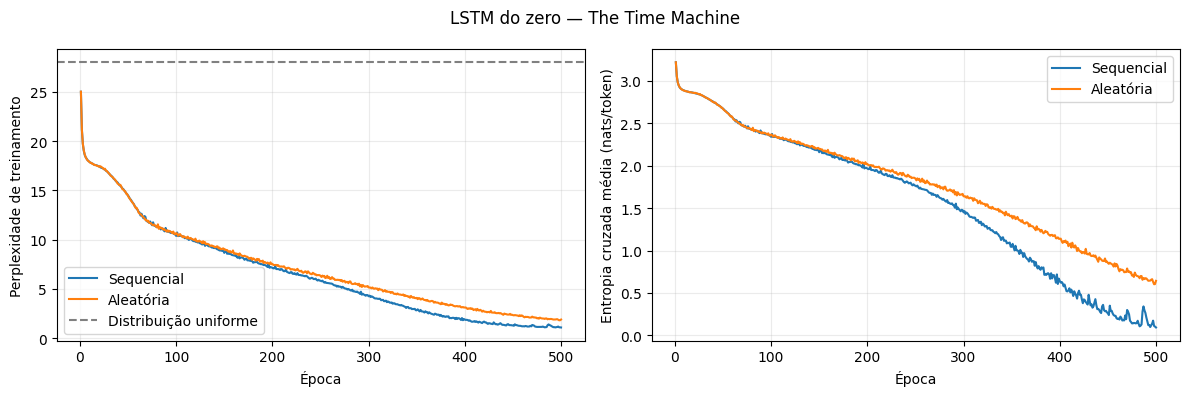

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, history in [("Sequencial", history_seq), ("Aleatória", history_random)]:
    if not history:
        continue
    epochs = [item["epoch"] for item in history]
    axes[0].plot(epochs, [item["perplexity"] for item in history], label=label)
    axes[1].plot(epochs, [item["loss"] for item in history], label=label)

axes[0].axhline(len(vocab), linestyle="--", color="gray", label="Distribuição uniforme")
axes[0].set_ylabel("Perplexidade de treinamento")
axes[1].set_ylabel("Entropia cruzada média (nats/token)")
for ax in axes:
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("LSTM do zero — The Time Machine")
fig.tight_layout()
plt.show()


In [14]:
for label, model, history in [
    ("Sequencial", net_seq, history_seq),
    ("Aleatória", net_random, history_random),
]:
    if model is None:
        continue
    print(f"\n{label} | perplexidade final de treino: {history[-1]['perplexity']:.3f}")
    for prefix in ("time traveller ", "traveller ", "the time machine "):
        print(predict(prefix, 50, model, vocab))



Sequencial | perplexidade final de treino: 1.097
time traveller for so it will be convenient to speak of himwas ex
traveller a somithed on stact and sediftey that breal tousta
the time machine travel hich was that seatle of the farmoms and ane

Aleatória | perplexidade final de treino: 1.901
time traveller smiled are you sure we can le beck instance here i
traveller smiled are you sure we can le beck instance here i
the time machine yloply his i neep about it always begon think this


## 10. Experimentos sugeridos

1. Compare os perfis `livro` e `rapido` e observe a qualidade do texto gerado.
2. Compare RNN, GRU e LSTM usando o mesmo tamanho oculto, as mesmas épocas,
   o mesmo corpus e o mesmo dispositivo. Registre também o número de
   parâmetros: igualar o tamanho oculto não iguala a capacidade dos modelos.
3. Inspecione `I`, `F_gate`, `O`, `H` e `C` com `lstm_step` após o treinamento,
   usando os pesos de `net_seq`, e compare com os valores da inicialização.
4. Em `lstm_step`, experimente fixar `F_gate = torch.ones_like(F_gate)` ou
   `I = torch.zeros_like(I)` antes da atualização da memória. Treine modelos
   novos e observe o efeito de desativar o esquecimento ou a escrita.
5. Experimente inicializar `b_f` com 1 e compare com o valor 0 adotado no capítulo.
6. Para avaliar generalização, reserve um trecho contínuo para validação antes
   de criar os iteradores e calcule a perda sem atualizar os pesos.

A perplexidade exibida é de **treinamento**. Valores próximos de 1 podem
refletir memorização dos 10.000 caracteres. As portas ajudam a controlar o
fluxo de informação, mas não garantem aprendizado de dependências longas.
A semente favorece a repetição no mesmo ambiente; resultados entre versões
ou dispositivos podem variar.
